## ---------------------------------------------------------
## STAGE 0: Setup
## ---------------------------------------------------------

In [1]:
from sentence_transformers import CrossEncoder, InputExample
from datasets import load_dataset
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import math
from scipy.special import softmax
import torch
from torch import nn
import os
import random
import re
from collections import Counter
from kornia.losses import FocalLoss
from sklearn.model_selection import StratifiedKFold
import seaborn as sns
from sklearn.metrics import confusion_matrix
import gc
import json

In [2]:
def p_tagger(text):
    P_REGEX = r'\b(p(?:-value)?)\s*([<>=])\s*([0-9]*\.?[0-9])'
    def replace(m):
        pre, op, val = m.group(1), m.group(2), float(m.group(3))
        if val <= 0.05: tag = "[STATISTICALLY SIGNIFICANT]"
        elif 0.05 < val <= 0.10: tag = "[BORDERLINE SIGNIFICANCE]"
        else: tag = "[NOT SIGNIFICANT]"
        return f"{tag} {pre} {op} {val}"
    return re.sub(P_REGEX, replace, text)

def extract_results(row):
    lbls = row['context']['labels']
    cntxt = row['context']['contexts']
    text = None
    for i, lbl in enumerate(lbls):
        l = lbl.upper()
        if l in ["RESULT", "RESULTS"]: text = cntxt[i]
    if text is None: text = cntxt[-1]
    return p_tagger(text)

mapping = {"no": 0, "maybe": 1, "yes": 2}

def load_art():
    art = load_dataset("pubmed_qa", "pqa_artificial", split ='train')
    art_yes = [row for row in art if row['final_decision'] == 'yes']
    art_no = [row for row in art if row['final_decision'] == 'no']
    art = random.sample(art_yes, 5000) + random.sample(art_no, 5000)
    art_normal = []
    art_teacher = []
    for row in art:
        results = extract_results(row) 
        art_normal.append(InputExample(
            texts = [row['question'], results],
            label = mapping[row['final_decision']]
        ))
        art_teacher.append(InputExample(
            texts = [f"[QUESTION] {row['question']}", f"[CONCLUSION] {row['long_answer']}"], 
            label = mapping[row['final_decision']]
        ))
    return art_normal, art_teacher
art_normal, art_teacher = load_art()

def load_labeld():
    labeld = load_dataset("pubmed_qa", "pqa_labeled", split ='train')
    labeld_normal = []
    labeld_teacher = []
    labeld_ids = []
    for row in labeld:
        results = extract_results(row)
        labeld_normal.append(InputExample(
            texts = [f"[QUESTION] {row['question']}", f"[CONTEXT] {results}"],
            label = mapping[row['final_decision']]
        ))
        labeld_teacher.append(InputExample(
            texts = [f"[QUESTION] {row['question']}", f"[CONCLUSION] {row['long_answer']}"], 
            label = mapping[row['final_decision']]
        ))
        labeld_ids.append(str(row['pubid']))
    return labeld_normal, labeld_teacher, labeld_ids
labeld_normal, labeld_teacher, labeld_ids = load_labeld()

def load_unlabeld():
    unlabeld = load_dataset("pubmed_qa", "pqa_unlabeled", split = 'train')
    unlabeld_teacher = []
    for row in unlabeld:
        unlabeld_teacher.append([f"[QUESTION] {row['question']}", f"[CONCLUSION] {row['long_answer']}"])
    return unlabeld, unlabeld_teacher
unlabeld_normal, unlabeld_teacher = load_unlabeld()

## ---------------------------------------------------------
## STAGE 1: Pre-training on Artificial (PQA-A)
## ---------------------------------------------------------

In [3]:
model_nm = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'
def warmup_training():
    artloader = DataLoader(art_normal, shuffle = True, batch_size = 8)
    model_mainn = CrossEncoder(model_nm, num_labels = 3)
    new_tkns = ["[STATISTICALLY SIGNIFICANT]", "[BORDERLINE SIGNIFICANCE]", "[NOT SIGNIFICANT]"]
    model_mainn.tokenizer.add_special_tokens({'additional_special_tokens': new_tkns})
    model_mainn.model.resize_token_embeddings(len( model_mainn.tokenizer))
    model_mainn.fit(
        train_dataloader = artloader,
        epochs = 1,
        loss_fct = nn.CrossEntropyLoss(label_smoothing = 0.1),
        optimizer_params = {'lr': 8e-6},
        warmup_steps = math.ceil(len(artloader) * 1 * 0.1))
    model_mainn.save('stage1_art')
    return model_mainn
model_mainn = warmup_training()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Step,Training Loss
500,0.699510
1000,0.518108


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## ---------------------------------------------------------
## STAGE 2: Train Teacher and Pseudo-Label Acquisition
## ---------------------------------------------------------

In [5]:
def teacher_training():
    teacher = CrossEncoder(model_nm, num_labels = 3)
    artloader2 = DataLoader(art_teacher, shuffle = True, batch_size = 8)
    teacher.fit(
        train_dataloader = artloader2, 
        epochs = 2, 
        loss_fct = nn.CrossEntropyLoss(label_smoothing = 0.1), 
        optimizer_params = {'lr': 8e-6},
        warmup_steps = math.ceil(len(artloader2) * 2 * 0.1))
    labeld_loader = DataLoader(labeld_teacher, batch_size = 16)
    weights = 1.0 / (np.bincount([ex.label for ex in labeld_teacher]))
    teacher.fit(
        train_dataloader=labeld_loader,
        epochs = 8, 
        loss_fct = nn.CrossEntropyLoss(weight = torch.tensor(weights, dtype = torch.float).cuda()),
        optimizer_params = {'lr': 8e-6},
        warmup_steps = math.ceil(len(labeld_loader) * 8 * 0.1))
    return teacher
teacher = teacher_training()

def extract_pseudo():
    scores = teacher.predict(unlabeld_teacher, batch_size = 8)
    probs = softmax(scores, axis = 1)
    confidences = np.max(probs, axis = 1)
    predicted = np.argmax(probs, axis = 1)
    no = []
    maybe = []
    yes = []
    for i in range( len(predicted)):
        if predicted[i] == 0: no.append((i, confidences[i]))
        elif predicted[i] == 1: maybe.append((i, confidences[i]))
        else: yes.append((i, confidences[i])) 
    no.sort(key = lambda x: x[1], reverse = True)
    maybe.sort(key = lambda x: x[1], reverse = True)
    yes.sort(key = lambda x: x[1], reverse = True)
    pseudo = []
    
    no_count = 0
    for smpl in no:
        if no_count == 2000:
            break
        idx = smpl[0]
        results = extract_results(unlabeld_normal[idx])
        pseudo.append(InputExample(texts = [f"[QUESTION] {unlabeld_normal[idx]['question']}", f"[CONTEXT] {results}"],  label = 0))
        no_count += 1
    maybe_count = 0
    for smpl in maybe:        
        if maybe_count == 1500:
            break
        idx = smpl[0]
        results = extract_results(unlabeld_normal[idx])
        pseudo.append(InputExample(texts = [f"[QUESTION] {unlabeld_normal[idx]['question']}", f"[CONTEXT] {results}"], label = 1))
        maybe_count += 1
    yes_count = 0
    for smpl in yes:
        if yes_count == 2000:
            break
        idx = smpl[0]
        results = extract_results(unlabeld_normal[idx])
        pseudo.append(InputExample(texts = [f"[QUESTION] {unlabeld_normal[idx]['question']}", f"[CONTEXT] {results}"], label = 2))
        yes_count += 1
    return pseudo
pseudo = extract_pseudo()

def pseudo_training():
    pseudo_loadr = DataLoader(pseudo, shuffle = True, batch_size = 32)
    model_mainn = CrossEncoder('stage1_art', num_labels = 3)
    model_mainn.fit(
        train_dataloader = pseudo_loadr,
        epochs = 6, 
        loss_fct = nn.CrossEntropyLoss(label_smoothing = 0.05),
        optimizer_params={'lr': 8e-6},
        warmup_steps = math.ceil(len(pseudo_loadr) * 6 * 0.1)
    )
    model_mainn.save('stage2_pseudo')
    return model_mainn
modl_mainn = pseudo_training()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Step,Training Loss
500,0.594089
1000,0.412321
1500,0.384864
2000,0.367482
2500,0.355840


Step,Training Loss
500,0.605736


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Step,Training Loss
500,0.517181
1000,0.324126


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## ---------------------------------------------------------
## STAGE 3: Fine-Tuning on Labeled (PQA-L)
## ---------------------------------------------------------

In [6]:
with open('ground_truth_test.json', 'r') as f:
    ground_truth = json.load(f)
tesids = set(ground_truth.keys())
offic_test, offic_dev = [], []
for i, row in enumerate(labeld_normal):
    if labeld_ids[i] in tesids: offic_test.append(row)
    else: offic_dev.append(row)

def labeld_training():
    dev = np.array(offic_dev, dtype = object)
    dev_lbls = np.array([d.label for d in offic_dev])
    skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
    for i, (trn, _) in enumerate(skf.split(dev, dev_lbls)):
        modl_mainn = CrossEncoder('stage2_pseudo', num_labels = 3)
        train_loadr = DataLoader(dev[trn].tolist(), shuffle = True, batch_size = 8)
        modl_mainn.fit(
            train_dataloader = train_loadr,
            epochs = 6,
            loss_fct = FocalLoss(alpha = 1.0, gamma = 1.5, reduction = 'mean'),
            optimizer_params = {'lr': 8e-6})
        modl_mainn.save(f'fold_{i}')
labeld_training()

test = [[t.texts[0], t.texts[1]] for t in offic_test]
lbls = [t.label for t in offic_test]
all_predictons = []
for i in range(10):
    modl_mainn = CrossEncoder(f'fold_{i}')
    logits = modl_mainn.predict(test)
    all_predictons.append(logits)
meanss = np.mean(all_predictons, axis = 0)
final = np.argmax(meanss, axis = 1)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Step,Training Loss


...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## ---------------------------------------------------------
## STAGE 4: Results
## ---------------------------------------------------------

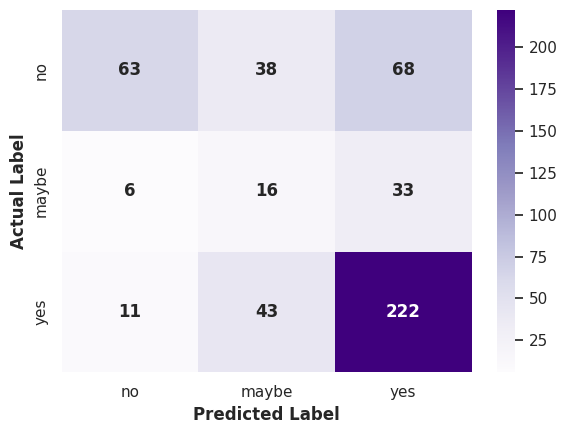

In [7]:
cm = confusion_matrix(lbls, final)
plt.figure(figsize=(6, 4.5))
sns.set_theme(style="white")
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels = ["no", "maybe", "yes"], 
            yticklabels = ["no", "maybe", "yes"],
            annot_kws={'weight': 'bold'})

plt.ylabel('Actual Label', fontsize = 12, fontweight = 'bold')
plt.xlabel('Predicted Label', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.savefig("test_set_confusion_matrix.png", dpi = 300)
plt.show()